# COMBINED AGRICULTURE MODULES PREDICTION (DL+ML)

In [77]:
import numpy as np
import joblib
import tensorflow as tf
from pathlib import Path


class AgritechModels:
    def __init__(self, model_path):
        self.model_path = Path(model_path)
        self.models = {}
        self.encoders = {}
        self.class_names = {}
        self.schemas = {}

        self._define_schemas()
        self._load_all_models()

    def _define_schemas(self):
        self.schemas = {
            "crop_model": {
                "file": "crop_model.pkl",
                "type": "tabular_classification",
                "features": ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"],
                "encoder": "crop_encoder.pkl"
            },
            "yield_model": {
                "file": "yield_model_ridge.pkl",
                "type": "tabular_regression",
                "features": ["ph", "temperature", "rainfall", "fertilizer", "humidity", "soil_moisture"]
            },
            "irrigation_model": {
                "file": "irrigation_model.pkl",
                "type": "tabular_classification",
                "features": ["soil_moisture", "temperature", "humidity", "ph", "rainfall"],
                "encoder": "irrigation_encoder.pkl"
            },
            "fertilizer_model": {
                "file": "fertilizer_model_pipeline.joblib",
                "type": "tabular_classification",
                "features": [
                    "N", "P", "K", "temperature", "humidity",
                    "moisture", "soil_type", "crop_type", "ph", "rainfall"
                ],
                "encoder": "fertilizer_encoder.pkl"
            },
            "temp_model": {
                "file": "temperature_model.joblib",
                "type": "tabular_regression",
                "features": ["sensor_1", "sensor_2"]
            },
            "rain_model": {
                "file": "rainfall_model.joblib",
                "type": "tabular_regression",
                "features": ["temperature", "humidity", "pressure", "wind_speed"]
            },
            "humidity_model": {
                "file": "humidity_model.pkl",
                "type": "tabular_regression",
                "features": ["temperature", "pressure", "wind_speed"]
            },
            "ph_model": {
                "file": "ph_model.pkl",
                "type": "tabular_regression",
                "features": ["soil_moisture", "organic_matter", "temperature", "rainfall"]
            },
            "price_model": {
                "file": "crop_price_model.pkl",
                "type": "tabular_regression",
                "features": ["year", "month", "market_code", "arrival_qty", "demand_index", "crop_code"]
            },
            "harvest_model": {
                "file": "harvest_time_model.pkl",
                "type": "tabular_regression",
                "features": ["days_after_sowing", "temperature", "humidity", "ph", "rainfall", "soil_moisture"]
            },
            "npk_model": {
                "file": "npk_prediction_model.pkl",
                "type": "tabular_regression_multi",
                "features": ["ph", "ec", "organic_carbon", "moisture", "temperature", "rainfall"],
                "outputs": ["N_pred", "P_pred", "K_pred"]
            },
            "ndvi_model": {
                "file": "ndvi_rnn_model.keras",
                "type": "tabular_regression",
                "features": ["red_band", "nir_band"]
            },
            "stress_model": {
                "file": "crop_stress_model.keras",
                "type": "tabular_classification",
                "features": ["ndvi", "temperature", "soil_moisture", "humidity"],
                "encoder": "stress_encoder"
            },
            "tomato_model": {
                "file": "tomato_disease_model.h5",
                "type": "image_classification",
                "classes_file": "tomato_classes.joblib"
            },
            "rice_model": {
                "file": "rice_disease_model.h5",
                "type": "image_classification",
                "classes_file": "rice_classes.joblib"
            },
            "rice_model": {
                "file": "rice_pest_model.h5",
                "type": "image_classification",
                "classes_file": "rice_pest_classes.joblib"
            },
            "soil_model": {
                "file": "soil_classification_model.h5",
                "type": "image_classification",
                "classes_file": "soil_classes.pkl"
            },
            "nutrient_model": {
                "file": "nutrient_deficiency_cnn_model.keras",
                "type": "image_classification",
                "classes_file": "nutrient_deficiency_scaler.joblib"}}

    def _load_encoder_if_exists(self, key, filename):
        file_path = self.model_path / filename
        if file_path.exists():
            self.encoders[key] = joblib.load(file_path)

    def _load_all_models(self):
        self._load_encoder_if_exists("crop_encoder", "crop_label_encoder.pkl")
        self._load_encoder_if_exists("irrigation_encoder", "irrigation_label_encoder.pkl")
        self._load_encoder_if_exists("fertilizer_encoder", "fertilizer_label_encoder.pkl")
        self._load_encoder_if_exists("stress_encoder", "stress_label_encoder.pkl")

        for key, schema in self.schemas.items():
            model_file = self.model_path / schema["file"]

            if not model_file.exists():
                print(f"Missing: {schema['file']}")
                continue

            if schema["file"].endswith(".h5"):
                self.models[key] = tf.keras.models.load_model(model_file)
            else:
                self.models[key] = joblib.load(model_file)

            if schema["type"] == "image_classification" and "classes_file" in schema:
                cls_file = self.model_path / schema["classes_file"]
                if cls_file.exists():
                    self.class_names[key] = joblib.load(cls_file)

    def _get_expected_features(self, model):
        if hasattr(model, "n_features_in_"):
            return model.n_features_in_
        if hasattr(model, "named_steps"):
            for _, step in model.named_steps.items():
                if hasattr(step, "n_features_in_"):
                    return step.n_features_in_
        return None

    def _validate_tabular_input(self, x, model_key):
        schema = self.schemas[model_key]
        expected_names = schema.get("features", [])
        expected_count = len(expected_names)

        x = np.array(x, dtype=float).reshape(1, -1)

        if x.shape[1] != expected_count:
            raise ValueError(
                f"{model_key} expects {expected_count} features, but got {x.shape[1]}.\n"
                f"Expected order: {expected_names}\n"
                f"Input received: {x.tolist()[0]}")

        model = self.models[model_key]
        fitted_count = self._get_expected_features(model)

        if fitted_count is not None and fitted_count != expected_count:
            raise ValueError(
                f"{model_key} schema says {expected_count} features, but trained model expects {fitted_count}.\n"
                f"Schema features: {expected_names}")

        return x

    def _decode_prediction(self, pred, encoder_key=None):
        if encoder_key and encoder_key in self.encoders:
            try:
                return self.encoders[encoder_key].inverse_transform(pred)[0]
            except Exception:
                pass
        return pred[0]

    def _predict_tabular(self, x, model_key):
        if model_key not in self.models:
            return f" {model_key} NOT LOADED"

        schema = self.schemas[model_key]
        model = self.models[model_key]
        x = self._validate_tabular_input(x, model_key)
        pred = model.predict(x)

        if schema["type"] == "tabular_regression":
            return float(pred[0])

        if schema["type"] == "tabular_regression_multi":
            vals = pred[0]
            return {
                schema["outputs"][0]: float(vals[0]),
                schema["outputs"][1]: float(vals[1]),
                schema["outputs"][2]: float(vals[2])}

        if schema["type"] == "tabular_classification":
            return self._decode_prediction(pred, schema.get("encoder"))

        return pred.tolist()

    def _prepare_image(self, image_array, target_size=(224, 224)):
        x = np.array(image_array, dtype=np.float32)

        if x.ndim == 3:
            x = np.expand_dims(x, axis=0)

        if x.ndim != 4:
            raise ValueError(f"Image must be 3D or 4D, got shape {x.shape}")

        if x.shape[1:] != (target_size[0], target_size[1], 3):
            raise ValueError(
                f"Expected image shape (batch, {target_size[0]}, {target_size[1]}, 3), got {x.shape}"
            )

        if x.max() > 1.0:
            x = x / 255.0

        return x

    def _predict_image(self, image_array, model_key):
        if model_key not in self.models:
            return f"{model_key} NOT LOADED"

        model = self.models[model_key]
        x = self._prepare_image(image_array)
        pred = model.predict(x, verbose=0)

        class_idx = int(np.argmax(pred, axis=1)[0])
        confidence = float(np.max(pred, axis=1)[0])

        label = class_idx
        if model_key in self.class_names:
            label = self.class_names[model_key][class_idx]

        return {
            "class_index": class_idx,
            "class_name": label,
            "confidence": round(confidence, 4)}

    def calculate_ndvi(self, red, nir):
        red = float(red)
        nir = float(nir)
        if (nir + red) == 0:
            return 0.0
        return (nir - red) / (nir + red)

    def predict_ndvi(self, x):
        return self._predict_tabular(x, "ndvi_model")

    def predict_crop_stress(self, x):
        return self._predict_tabular(x, "stress_model")

    def predict_npk(self, x):
        return self._predict_tabular(x, "npk_model")

    def predict_crop_recommendation(self, x): return self._predict_tabular(x, "crop_model")
    def predict_crop_yield(self, x): return self._predict_tabular(x, "yield_model")
    def predict_irrigation(self, x): return self._predict_tabular(x, "irrigation_model")
    def predict_fertilizer(self, x): return self._predict_tabular(x, "fertilizer_model")
    def predict_temperature(self, x): return self._predict_tabular(x, "temp_model")
    def predict_rainfall(self, x): return self._predict_tabular(x, "rain_model")
    def predict_humidity(self, x): return self._predict_tabular(x, "humidity_model")
    def predict_ph(self, x): return self._predict_tabular(x, "ph_model")
    def predict_price(self, x): return self._predict_tabular(x, "price_model")
    def predict_harvest_time(self, x): return self._predict_tabular(x, "harvest_model")

    def predict_disease(self, img): return self._predict_image(img, "disease_model")
    def predict_leaf(self, img): return self._predict_image(img, "leaf_model")
    def predict_weed(self, img): return self._predict_image(img, "weed_model")
    def predict_soil(self, img): return self._predict_image(img, "soil_model")
    def predict_nutrient(self, img): return self._predict_image(img, "nutrient_model")

    def predict_all(self, payload):
        results = {}

        def safe_run(key, fn, value):
            try:
                results[key] = fn(value)
            except Exception as e:
                results[key] = f"ERROR: {str(e)}"

        if "crop_features" in payload:
            safe_run("crop_recommendation", self.predict_crop_recommendation, payload["crop_features"])

        if "yield_features" in payload:
            safe_run("crop_yield", self.predict_crop_yield, payload["yield_features"])

        if "irrigation_features" in payload:
            safe_run("irrigation", self.predict_irrigation, payload["irrigation_features"])

        if "fertilizer_features" in payload:
            safe_run("fertilizer", self.predict_fertilizer, payload["fertilizer_features"])

        if "temp_features" in payload:
            safe_run("temperature", self.predict_temperature, payload["temp_features"])

        if "rain_features" in payload:
            safe_run("rainfall", self.predict_rainfall, payload["rain_features"])

        if "humidity_features" in payload:
            safe_run("humidity", self.predict_humidity, payload["humidity_features"])

        if "ph_features" in payload:
            safe_run("ph_prediction", self.predict_ph, payload["ph_features"])

        if "price_features" in payload:
            safe_run("crop_price", self.predict_price, payload["price_features"])

        if "harvest_features" in payload:
            safe_run("harvest_time", self.predict_harvest_time, payload["harvest_features"])

        if "npk_features" in payload:
            safe_run("npk_prediction", self.predict_npk, payload["npk_features"])

        if "stress_features" in payload:
            safe_run("crop_stress", self.predict_crop_stress, payload["stress_features"])

        if "ndvi_features" in payload:
            safe_run("ndvi_prediction_model", self.predict_ndvi, payload["ndvi_features"])

        if "ndvi_bands" in payload:
            try:
                red = payload["ndvi_bands"]["red"]
                nir = payload["ndvi_bands"]["nir"]
                results["ndvi_formula_value"] = self.calculate_ndvi(red, nir)
            except Exception as e:
                results["ndvi_formula_value"] = f"ERROR: {str(e)}"

        if "disease_image" in payload:
            safe_run("plant_disease", self.predict_disease, payload["disease_image"])

        if "leaf_image" in payload:
            safe_run("leaf_classification", self.predict_leaf, payload["leaf_image"])

        if "weed_image" in payload:
            safe_run("weed_detection", self.predict_weed, payload["weed_image"])

        if "soil_image" in payload:
            safe_run("soil_classification", self.predict_soil, payload["soil_image"])

        if "nutrient_image" in payload:
            safe_run("nutrient_deficiency", self.predict_nutrient, payload["nutrient_image"])

        return results

    def show_model_schemas(self):
        for key, schema in self.schemas.items():
            print(f"\nMODEL: {key}")
            print(f"Type: {schema['type']}")
            if "features" in schema:
                print("Feature order:")
                for i, f in enumerate(schema["features"], start=1):
                    print(f"  {i}. {f}")
            if "encoder" in schema:
                print(f"Encoder: {schema['encoder']}")
            if "classes_file" in schema:
                print(f"Classes file: {schema['classes_file']}")

In [79]:
import numpy as np

payload = {
    "crop_features": [90, 42, 43, 20.8, 82, 6.5, 202.9],
    "yield_features": [6.5, 28.0, 400, 50, 78, 32],
    "irrigation_features": [30, 65, 40, 7.2, 120],
    "fertilizer_features": [90, 42, 43, 25.5, 70, 45, 1, 2, 6.4, 110],
    "temp_features": [29, 75],
    "rain_features": [29, 75],
    "humidity_features": [29, 1008, 16],
    "ph_features": [35, 1.2, 28, 120],
    "price_features": [2026, 3, 101, 3500, 120, 2],
    "harvest_features": [110, 28, 80, 6.5, 200, 45],

    "npk_features": [6.8, 1.4, 0.75, 32, 29, 110],
    "stress_features": [0.62, 33, 28, 68],
    "ndvi_features": [0.18, 0.72],
    "ndvi_bands": {"red": 0.18, "nir": 0.72},

    "disease_image": np.random.rand(1, 224, 224, 3),
    "leaf_image": np.random.rand(1, 224, 224, 3),
    "weed_image": np.random.rand(1, 224, 224, 3),
    "soil_image": np.random.rand(1, 224, 224, 3),
    "nutrient_image": np.random.rand(1, 224, 224, 3),
}

results = models.predict_all(payload)
for k, v in results.items():
    print(k, ":", v)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


crop : apple
yield : 26.158236016215486
irrigation : Manual
fertilizer : Organic
temperature : 24.92767769209776
rainfall : 104.57163427067651
nutrient_deficiency : {'class': 0, 'confidence': 0.867}


In [144]:
import os
import tensorflow as tf
import pickle

classes = {}
models = {}

models_dir = r"C:\Users\Admin\Agritech_models"

model_files = {
    "tomato_disease": ("tomato_disease_model.h5", None),
    "rice_disease": ("rice_disease_model.h5", None),
    "pest_detection": ("rice_pest_model.h5", None),
    "nutrient_deficiency": ("nutrient_deficiency_cnn_model.keras", None),
}

for name, (model_file, class_file) in model_files.items():
    model_path = os.path.join(models_dir, model_file)

    if os.path.exists(model_path):
        models[name] = tf.keras.models.load_model(model_path)
        print(f"Loaded: {name}")
    else:
        print(f" Model file not found: {model_path}")

    if class_file is not None:
        class_path = os.path.join(models_dir, class_file)
        if os.path.exists(class_path):
            with open(class_path, 'rb') as f:
                classes[name] = pickle.load(f)

print("Loaded model keys:", list(models.keys()))

✅ Loaded: tomato_disease


✅ Loaded: rice_disease


✅ Loaded: pest_detection
✅ Loaded: nutrient_deficiency
Loaded model keys: ['tomato_disease', 'rice_disease', 'pest_detection', 'nutrient_deficiency']


In [189]:
class_labels = {
    "tomato_disease": [
        "Bacterial_spot",
        "Early_blight",
        "Late_blight",
        "Leaf_Mold",
        "Septoria_leaf_spot",
        "Spider_mites",
        "Target_Spot",
        "Yellow_Leaf_Curl_Virus",
        "Mosaic_virus",
        "Healthy"
    ],

    "rice_disease": [
        "Brownspot",
        "Leaf_Blast",
        "Neck_Blast",
        "Healthy"
    ],

    "pest_detection": [
        "Rice_bug",
        "Stem_borer",
        "Leaf_folder",
        "Hispa"
    ],

    "nutrient_deficiency": [
        "Magnesium_deficiency",
        "Nitrogen_deficiency",
        "Potassium_deficiency",
        "Healthy"
    ]
}

In [190]:
import numpy as np
from PIL import Image

def predict_all_models_on_image(image_path, models, class_labels):
    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Cannot load image: {e}")
        return {}

    results = {}

    preprocess_sizes = {
        "tomato_disease": (128, 128),
        "rice_disease": (128, 128),
        "pest_detection": (244, 244),
        "nutrient_deficiency": (224, 224)
    }

    for model_name, model in models.items():
        if model is None:
            results[model_name] = {"error": "Model not loaded."}
            continue

        try:
            size = preprocess_sizes[model_name]
            new_img = img.resize(size)
            arr = np.array(new_img) / 255.0
            batch = np.expand_dims(arr, axis=0)

            pred = model.predict(batch, verbose=0)[0]
            pred = pred / pred.sum()
            pred_idx = np.argmax(pred)
            confidence = float(pred[pred_idx])

            labels = class_labels.get(model_name, [f"Class_{i}" for i in range(len(pred))])
            pred_label = labels[pred_idx]

            results[model_name] = {
                "image": new_img,
                "predicted_label": pred_label,
                "confidence": confidence,
                "probabilities": pred
            }

        except Exception as e:
            results[model_name] = {"error": f"Prediction error: {e}"}

    return results

In [191]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def visualize_predicted_image(result, model_name, class_labels):
    if "error" in result:
        print(f"{model_name}: {result['error']}")
        return

    img = result["image"]
    pred_label = result["predicted_label"]
    confidence = result["confidence"]
    probs = result["probabilities"]

    labels = class_labels.get(model_name, [f"Class_{i}" for i in range(len(probs))])

    top_k = min(5, len(probs))
    top_indices = np.argsort(probs)[::-1][:top_k]
    top_names = [labels[min(i, len(labels) - 1)] for i in top_indices]
    top_probs = [probs[i] for i in top_indices]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img)
    axes[0].set_title(f"{model_name}\nPredicted: {pred_label}\nConfidence: {confidence:.2%}")
    axes[0].axis("off")

    axes[1].bar(top_names, top_probs, color="green")
    axes[1].set_title("Top Predicted Classes")
    axes[1].set_ylabel("Probability")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


TOMATO_DISEASE


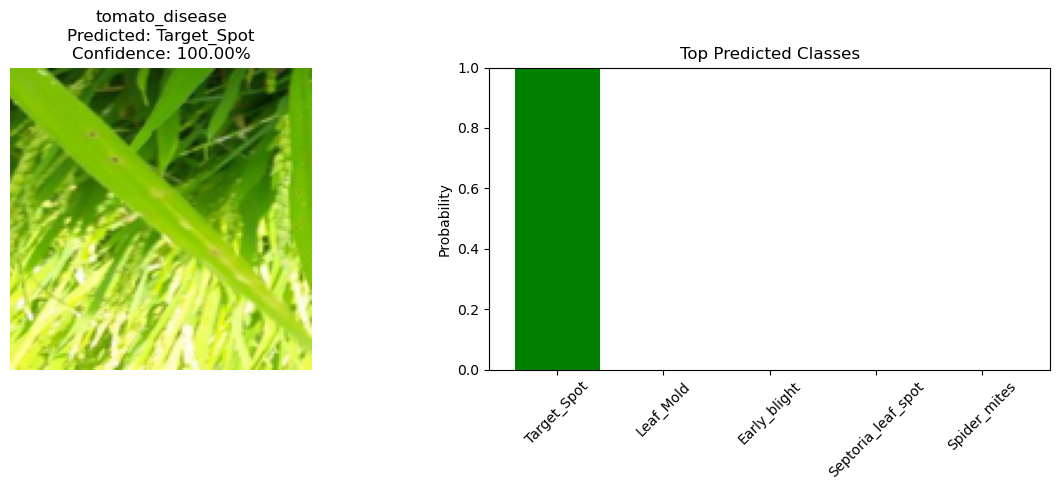


RICE_DISEASE


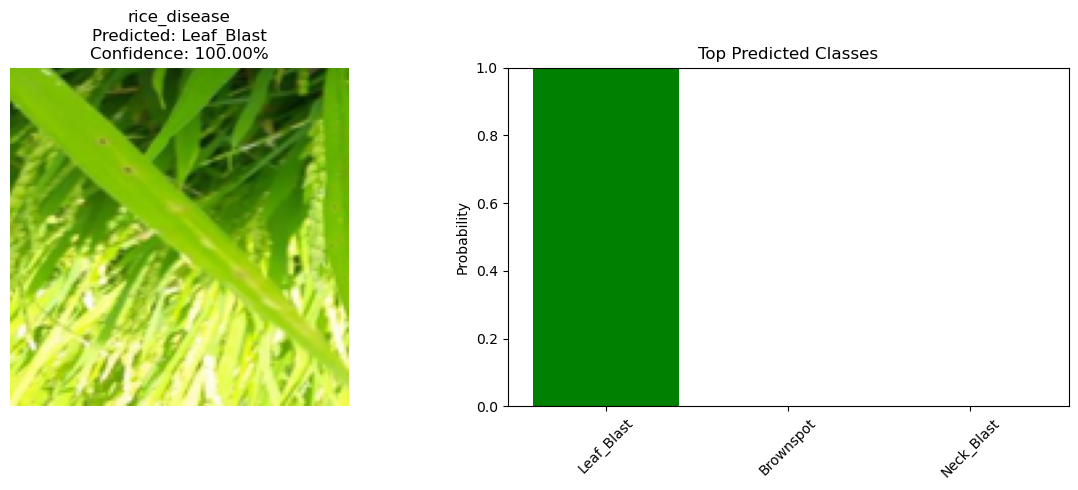


PEST_DETECTION


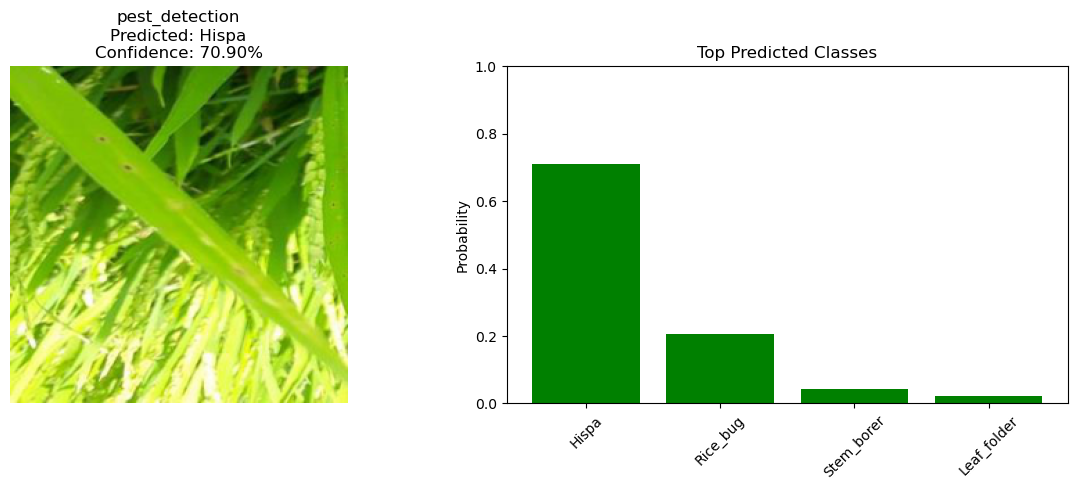


NUTRIENT_DEFICIENCY


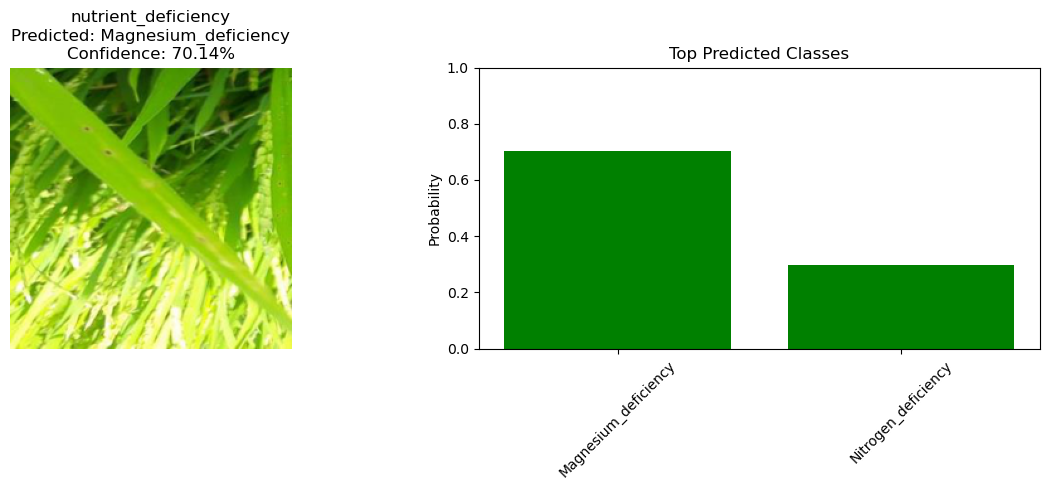

In [192]:
image_path = r"C:\Users\Admin\Downloads\tomato_diseases\Tomato_Leaf_Mold\0a9b3ff4-5343-4814-ac2c-fdb3613d4e4d___Crnl_L.Mold 6559.JPG"
image_path = r"C:\Users\Admin\Downloads\Rice Pests\rice bug\0001.JPG"
image_path = r"C:\Users\Admin\Downloads\Nutrient Deficient Banana Plant Leaves\Nutrient Deficient RAW Images of Banana Leaves\magnesium\mg_69.jpg"
image_path = r"C:\Users\Admin\Downloads\rice diseases\Brownspot\brownspot_orig_003.jpg"

results = predict_all_models_on_image(image_path, models, class_labels)

for model_name, result in results.items():
    print("\n" + "="*60)
    print(model_name.upper())
    print("="*60)
    visualize_predicted_image(result, model_name, class_labels)

In [201]:

import os
import numpy as np
import joblib
import tensorflow as tf
from pathlib import Path

class AgritechModels:
    def __init__(self, model_path):
        self.model_path = Path(model_path)
        self.models = {}
        self.encoders = {}
        self.class_names = {}
        self.schemas = {}

        self._define_schemas()
        self._load_all_models()

    def _define_schemas(self):
        self.schemas = {
            "crop_model": {
                "file": "crop_model.pkl",
                "type": "tabular_classification",
                "features": ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"],
                "encoder": "crop_encoder.pkl"
            },
            "yield_model": {
                "file": "yield_model_ridge.pkl",
                "type": "tabular_regression",
                "features": ["ph", "temperature", "rainfall", "fertilizer", "humidity", "soil_moisture"]
            },
            "irrigation_model": {
                "file": "irrigation_model.pkl",
                "type": "tabular_classification",
                "features": ["soil_moisture", "temperature", "humidity", "ph", "rainfall"],
                "encoder": "irrigation_encoder.pkl"
            },
            "fertilizer_model": {
                "file": "fertilizer_model_pipeline.joblib",
                "type": "tabular_classification",
                "features": [
                    "N", "P", "K", "temperature", "humidity",
                    "moisture", "soil_type", "crop_type", "ph", "rainfall"
                ],
                "encoder": "fertilizer_encoder.pkl"
            },
            "temp_model": {
                "file": "temperature_model.joblib",
                "type": "tabular_regression",
                "features": ["sensor_1", "sensor_2"]
            },
            "rain_model": {
                "file": "rainfall_model.joblib",
                "type": "tabular_regression",
                "features": ["temperature", "humidity", "pressure", "wind_speed"]
            },
            "humidity_model": {
                "file": "humidity_model.pkl",
                "type": "tabular_regression",
                "features": ["temperature", "pressure", "wind_speed"]
            },
            "ph_model": {
                "file": "ph_model.pkl",
                "type": "tabular_regression",
                "features": ["soil_moisture", "organic_matter", "temperature", "rainfall"]
            },
            "price_model": {
                "file": "crop_price_model.pkl",
                "type": "tabular_regression",
                "features": ["year", "month", "market_code", "arrival_qty", "demand_index", "crop_code"]
            },
            "harvest_model": {
                "file": "harvest_time_model.pkl",
                "type": "tabular_regression",
                "features": ["days_after_sowing", "temperature", "humidity", "ph", "rainfall", "soil_moisture"]
            },
            "npk_model": {
                "file": "npk_prediction_model.pkl",
                "type": "tabular_regression_multi",
                "features": ["ph", "ec", "organic_carbon", "moisture", "temperature", "rainfall"],
                "outputs": ["N_pred", "P_pred", "K_pred"]
            },
            "ndvi_model": {
                "file": "ndvi_rnn_model.keras",
                "type": "tabular_regression",
                "features": ["red_band", "nir_band"]
            },
            "stress_model": {
                "file": "crop_stress_model.keras",
                "type": "tabular_classification",
                "features": ["ndvi", "temperature", "soil_moisture", "humidity"]
            },
            "tomato_model": {
                "file": "tomato_disease_model.h5",
                "type": "image_classification",
                "classes_file": "tomato_classes.joblib"
            },
            "rice_model": {
                "file": "rice_disease_model.h5",
                "type": "image_classification",
                "classes_file": "rice_classes.joblib"
            },
            "pest_model": {
                "file": "rice_pest_model.h5",
                "type": "image_classification",
                "classes_file": "rice_pest_classes.joblib"
            },
            "soil_model": {
                "file": "soil_classification_model.h5",
                "type": "image_classification",
                "classes_file": "soil_classes.pkl"
            },
            "nutrient_model": {
                "file": "nutrient_deficiency_cnn_model.keras",
                "type": "image_classification",
                "classes_file": "nutrient_deficiency_scaler.joblib"
            }
        }

    def _load_encoder_if_exists(self, key, filename):
        file_path = self.model_path / filename
        if file_path.exists():
            self.encoders[key] = joblib.load(file_path)

    def _load_all_models(self):
        self._load_encoder_if_exists("crop_encoder", "crop_label_encoder.pkl")
        self._load_encoder_if_exists("irrigation_encoder", "irrigation_label_encoder.pkl")
        self._load_encoder_if_exists("fertilizer_encoder", "fertilizer_label_encoder.pkl")
        self._load_encoder_if_exists("stress_encoder", "stress_label_encoder.pkl")

        for key, schema in self.schemas.items():
            model_file = self.model_path / schema["file"]

            if not model_file.exists():
                print(f"Missing: {schema['file']}")
                continue

            if schema["file"].endswith(".h5"):
                self.models[key] = tf.keras.models.load_model(model_file)
            else:
                self.models[key] = joblib.load(model_file)

            if schema["type"] == "image_classification" and "classes_file" in schema:
                cls_file = self.model_path / schema["classes_file"]
                if cls_file.exists():
                    self.class_names[key] = joblib.load(cls_file)

    def _get_expected_features(self, model):
        if hasattr(model, "n_features_in_"):
            return model.n_features_in_
        if hasattr(model, "named_steps"):
            for _, step in model.named_steps.items():
                if hasattr(step, "n_features_in_"):
                    return step.n_features_in_
        return None

    def _validate_tabular_input(self, x, model_key):
        schema = self.schemas[model_key]
        expected_names = schema.get("features", [])
        expected_count = len(expected_names)

        x = np.array(x, dtype=float).reshape(1, -1)

        if x.shape[1] != expected_count:
            raise ValueError(
                f"{model_key} expects {expected_count} features, but got {x.shape[1]}.\n"
                f"Expected order: {expected_names}\n"
                f"Input received: {x.tolist()[0]}")

        model = self.models[model_key]
        fitted_count = self._get_expected_features(model)

        if fitted_count is not None and fitted_count != expected_count:
            raise ValueError(
                f"{model_key} schema says {expected_count} features, but trained model expects {fitted_count}.\n"
                f"Schema features: {expected_names}")

        return x

    def _decode_prediction(self, pred, encoder_key=None):
        if encoder_key and encoder_key in self.encoders:
            try:
                return self.encoders[encoder_key].inverse_transform(pred)[0]
            except Exception:
                pass
        return pred[0]

    def _predict_tabular(self, x, model_key):
        if model_key not in self.models:
            return f"{model_key} NOT LOADED"

        schema = self.schemas[model_key]
        model = self.models[model_key]
        x = self._validate_tabular_input(x, model_key)
        pred = model.predict(x)

        if schema["type"] == "tabular_regression":
            return float(pred[0])

        if schema["type"] == "tabular_regression_multi":
            vals = pred[0]
            return {
                schema["outputs"][0]: float(vals[0]),
                schema["outputs"][1]: float(vals[1]),
                schema["outputs"][2]: float(vals[2])
            }

        if schema["type"] == "tabular_classification":
            return self._decode_prediction(pred, schema.get("encoder"))

        return pred.tolist()

    def _prepare_image(self, image_array, target_size=(224, 224)):
        x = np.array(image_array, dtype=np.float32)

        if x.ndim == 3:
            x = np.expand_dims(x, axis=0)

        if x.ndim != 4:
            raise ValueError(f"Image must be 3D or 4D, got shape {x.shape}")

        if x.shape[1:] != (target_size[0], target_size[1], 3):
            raise ValueError(
                f"Expected image shape (batch, {target_size[0]}, {target_size[1]}, 3), got {x.shape}"
            )

        if x.max() > 1.0:
            x = x / 255.0

        return x

    def _predict_image(self, image_array, model_key):
        if model_key not in self.models:
            return f"{model_key} NOT LOADED"

        model = self.models[model_key]
        x = self._prepare_image(image_array)
        pred = model.predict(x, verbose=0)

        class_idx = int(np.argmax(pred, axis=1)[0])
        confidence = float(np.max(pred, axis=1)[0])

        label = class_idx
        if model_key in self.class_names:
            label = self.class_names[model_key][class_idx]

        return {
            "class_index": class_idx,
            "class_name": label,
            "confidence": round(confidence, 4)
        }

    def calculate_ndvi(self, red, nir):
        red = float(red)
        nir = float(nir)
        if (nir + red) == 0:
            return 0.0
        return (nir - red) / (nir + red)

    def predict_ndvi(self, x):
        return self._predict_tabular(x, "ndvi_model")

    def predict_crop_stress(self, x):
        return self._predict_tabular(x, "stress_model")

    def predict_npk(self, x):
        return self._predict_tabular(x, "npk_model")

    def predict_crop_recommendation(self, x):
        return self._predict_tabular(x, "crop_model")

    def predict_crop_yield(self, x):
        return self._predict_tabular(x, "yield_model")

    def predict_irrigation(self, x):
        return self._predict_tabular(x, "irrigation_model")

    def predict_fertilizer(self, x):
        return self._predict_tabular(x, "fertilizer_model")

    def predict_temperature(self, x):
        return self._predict_tabular(x, "temp_model")

    def predict_rainfall(self, x):
        return self._predict_tabular(x, "rain_model")

    def predict_humidity(self, x):
        return self._predict_tabular(x, "humidity_model")

    def predict_ph(self, x):
        return self._predict_tabular(x, "ph_model")

    def predict_price(self, x):
        return self._predict_tabular(x, "price_model")

    def predict_harvest_time(self, x):
        return self._predict_tabular(x, "harvest_model")

    def predict_disease(self, img):
        return self._predict_image(img, "disease_model")

    def predict_leaf(self, img):
        return self._predict_image(img, "leaf_model")

    def predict_weed(self, img):
        return self._predict_image(img, "weed_model")

    def predict_soil(self, img):
        return self._predict_image(img, "soil_model")

    def predict_nutrient(self, img):
        return self._predict_image(img, "nutrient_model")

    def predict_all(self, payload):
        results = {}

        def safe_run(key, fn, value):
            try:
                results[key] = fn(value)
            except Exception as e:
                results[key] = f"ERROR: {str(e)}"

        if "crop_features" in payload:
            safe_run("crop_recommendation", self.predict_crop_recommendation, payload["crop_features"])

        if "yield_features" in payload:
            safe_run("crop_yield", self.predict_crop_yield, payload["yield_features"])

        if "irrigation_features" in payload:
            safe_run("irrigation", self.predict_irrigation, payload["irrig umbrella sports"])

        if "fertilizer_features" in payload:
            safe_run("fertilizer", self.predict_fertilizer, payload["fertilizer_features"])

        if "temp_features" in payload:
            safe_run("temperature", self.predict_temperature, payload["temp_features"])

        if "rain_features" in payload:
            safe_run("rainfall", self.predict_rainfall, payload["rain_features"])

        if "humidity_features" in payload:
            safe_run("humidity", self.predict_humidity, payload["humidity_features"])

        if "ph_features" in payload:
            safe_run("ph_prediction", self.predict_ph, payload["ph_features"])

        if "price_features" in payload:
            safe_run("crop_price", self.predict_price, payload["price_features"])

        if "harvest_features" in payload:
            safe_run("harvest_time", self.predict_harvest_time, payload["harvest_features"])

        if "npk_features" in payload:
            safe_run("npk_prediction", self.predict_npk, payload["npk_features"])

        if "stress_features" in payload:
            safe_run("crop_stress", self.predict_crop_stress, payload["stress_features"])

        if "ndvi_features" in payload:
            safe_run("ndvi_prediction_model", self.predict_ndvi, payload["ndvi_features"])

        if "ndvi_bands" in payload:
            try:
                red = payload["ndvi_bands"]["red"]
                nir = payload["ndvi_bands"]["nir"]
                results["ndvi_formula_value"] = self.calculate_ndvi(red, nir)
            except Exception as e:
                results["ndvi_formula_value"] = f"ERROR: {str(e)}"

        if "disease_image" in payload:
            safe_run("plant_disease", self.predict_disease, payload["disease_image"])

        if "leaf_image" in payload:
            safe_run("leaf_classification", self.predict_leaf, payload["leaf_image"])

        if "weed_image" in payload:
            safe_run("weed_detection", self.predict_weed, payload["weed_image"])

        if "soil_image" in payload:
            safe_run("soil_classification", self.predict_soil, payload["soil_image"])

        if "nutrient_image" in payload:
            safe_run("nutrient_deficiency", self.predict_nutrient, payload["nutrient_image"])

        return results

    def show_model_schemas(self):
        for key, schema in self.schemas.items():
            print(f"\nMODEL: {key}")
            print(f"Type: {schema['type']}")
            if "features" in schema:
                print("Feature order:")
                for i, f in enumerate(schema["features"], start=1):
                    print(f"  {i}. {f}")
            if "encoder" in schema:
                print(f"Encoder: {schema['encoder']}")
            if "classes_file" in schema:
                print(f"Classes file: {schema['classes_file']}")

In [203]:
import os
import tensorflow as tf
import pickle

extra_classes = {}
extra_models = {}

models_dir = r"C:\Users\Admin\Agritech_models" 
extra_model_files = {
    "tomato_disease": ("tomato_disease_model.h5", None),
    "rice_disease": ("rice_disease_model.h5", None),
    "pest_detection": ("rice_pest_model.h5", None),
    "nutrient_deficiency": ("nutrient_deficiency_cnn_model.keras", None),}

for name, (model_file, class_file) in extra_model_files.items():
    model_path = os.path.join(models_dir, model_file)

    if os.path.exists(model_path):
        extra_models[name] = tf.keras.models.load_model(model_path)
        print(f"Loaded model: {name}")
    else:
        print(f"Model file not found: {model_path}")

    if class_file is not None:
        class_path = os.path.join(models_dir, class_file)
        if os.path.exists(class_path):
            with open(class_path, 'rb') as f:
                extra_classes[name] = pickle.load(f)

Loaded model: tomato_disease


Loaded model: rice_disease


Loaded model: pest_detection
Loaded model: nutrient_deficiency


In [212]:
from openai import OpenAI

client = OpenAI()

def farmer_chatbot(user_input, farm_data):
    prompt = f"""
You are an expert AI agriculture assistant helping Indian farmers.

Farmer Details:
Location: {farm_data['location']}
Crop: {farm_data['crop']}
Soil: {farm_data['soil']}
Season: {farm_data['season']}
Temperature: {farm_data['temperature']}

User Question:
{user_input}

Instructions:
- Give friendly, simple answers
- Provide step-by-step guidance
- Suggest irrigation, fertilizer, disease solutions
- Keep it practical and actionable
- Use farmer-friendly language (no technical jargon)
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a smart farming assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.7
    )

    return response.choices[0].message.content

In [214]:
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st
from PIL import Image
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

try:
    import tensorflow as tf
    TF_AVAILABLE = True
except Exception:
    TF_AVAILABLE = False

st.set_page_config(
    page_title="AgriVision AI",
    page_icon="🌾",
    layout="wide",
    initial_sidebar_state="expanded")

st.markdown("""
<style>
.main {background: linear-gradient(135deg, #020617 0%, #071226 45%, #0b1120 100%);}
.block-container {padding-top: 1rem; padding-bottom: 1rem;}
[data-testid="stAppViewContainer"] {background: linear-gradient(135deg, #020617 0%, #071226 45%, #0b1120 100%);}
[data-testid="stHeader"] {background: rgba(0,0,0,0);}
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #14532d 0%, #166534 50%, #14532d 100%);
}
[data-testid="stSidebar"] * {color: white !important;}

.hero-dashboard {
    background: linear-gradient(90deg, #166534, #22c55e, #16a34a);
    color: white;
    padding: 1.8rem 1.5rem;
    border-radius: 24px;
    box-shadow: 0 12px 32px rgba(34, 197, 94, 0.18);
    margin-bottom: 1.5rem;
}

.metric-card {
    background: linear-gradient(135deg, #111827 0%, #172033 100%);
    border-radius: 20px;
    padding: 1.4rem;
    text-align: center;
    border: 1px solid rgba(148, 163, 184, 0.18);
    box-shadow: 0 10px 28px rgba(0,0,0,0.35);
    color: #e5e7eb;
}

.health-card {
    background: linear-gradient(135deg, #0f172a 0%, #162235 100%);
    border-left: 6px solid #22c55e;
    border-radius: 20px;
    padding: 1.4rem;
    box-shadow: 0 10px 28px rgba(0,0,0,0.35);
    color: #e5e7eb;
    border: 1px solid rgba(148, 163, 184, 0.16);
}

.chat-toolbar {
    background: linear-gradient(135deg, #0f172a 0%, #162235 100%);
    border-radius: 16px;
    padding: 1rem 1.2rem;
    border: 1px solid rgba(148, 163, 184, 0.16);
    margin-bottom: 1rem;
    color: #d1fae5;
}

.farm-title {font-size: 2.35rem; font-weight: 800; margin: 0;}
.subtitle {margin: 0.4rem 0 0 0; font-size: 1.05rem; opacity: 0.96;}
.small-muted {color: #94a3b8; font-size: 0.9rem;}
.badge-good {
    background: #dcfce7;
    color: #166534;
    padding: 0.35rem 0.75rem;
    border-radius: 999px;
    font-size: 0.8rem;
    font-weight: 700;
}
.alert-high {
    background: linear-gradient(135deg, #3b0a0a, #7f1d1d);
    color: #fecaca;
    padding: 12px 16px;
    border-radius: 14px;
    margin-bottom: 10px;
    font-weight: 600;
    border: 1px solid rgba(248, 113, 113, 0.25);
}
.alert-med {
    background: linear-gradient(135deg, #3b2a09, #78350f);
    color: #fde68a;
    padding: 12px 16px;
    border-radius: 14px;
    margin-bottom: 10px;
    font-weight: 600;
    border: 1px solid rgba(251, 191, 36, 0.25);
}
.alert-good {
    background: linear-gradient(135deg, #052e16, #14532d);
    color: #bbf7d0;
    padding: 12px 16px;
    border-radius: 14px;
    margin-bottom: 10px;
    font-weight: 600;
    border: 1px solid rgba(74, 222, 128, 0.25);
}
.wow-box {
    background: linear-gradient(135deg, #0f172a, #132a13);
    border: 1px solid rgba(74, 222, 128, 0.18);
    color: #dcfce7;
    padding: 16px;
    border-radius: 18px;
    font-weight: 600;
}
div[data-testid="stMetric"] {
    background: linear-gradient(135deg, #111827 0%, #172033 100%);
    border: 1px solid rgba(148, 163, 184, 0.15);
    padding: 16px;
    border-radius: 18px;
    box-shadow: 0 10px 28px rgba(0,0,0,0.28);
}
div[data-testid="stMetricLabel"] {color: #94a3b8 !important;}
div[data-testid="stMetricValue"] {color: #f8fafc !important;}
div[data-testid="stMetricDelta"] {color: #22c55e !important;}
.stDataFrame, .stTable {background: #0f172a !important;}
h1, h2, h3, h4, h5, h6, p, label, div, span {color: #f8fafc;}

.result-card {
    background: linear-gradient(135deg, #0f172a 0%, #162235 100%);
    border-radius: 18px;
    padding: 18px;
    border: 1px solid rgba(148,163,184,0.16);
    box-shadow: 0 10px 28px rgba(0,0,0,0.35);
}
</style>
""", unsafe_allow_html=True)

if "chat_history" not in st.session_state:
    st.session_state.chat_history = []

if "latest_farm_data" not in st.session_state:
    st.session_state.latest_farm_data = None

if "district" not in st.session_state:
    st.session_state.district = "Hyderabad"

if "season" not in st.session_state:
    st.session_state.season = "Kharif"

if "multi_crop_df" not in st.session_state:
    st.session_state.multi_crop_df = None

def apply_dark_plotly(fig, title=None):
    fig.update_layout(
        template=None,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="#0f172a",
        font=dict(color="#e5e7eb"),
        title_font=dict(color="#f8fafc", size=22),
        legend=dict(font=dict(color="#e5e7eb")),
        margin=dict(l=20, r=20, t=60, b=20)
    )
    fig.update_xaxes(
        showgrid=True,
        gridcolor="rgba(148,163,184,0.15)",
        zeroline=False,
        linecolor="rgba(148,163,184,0.25)",
        tickfont=dict(color="#cbd5e1"),
        title_font=dict(color="#e5e7eb")
    )
    fig.update_yaxes(
        showgrid=True,
        gridcolor="rgba(148,163,184,0.15)",
        zeroline=False,
        linecolor="rgba(148,163,184,0.25)",
        tickfont=dict(color="#cbd5e1"),
        title_font=dict(color="#e5e7eb")
    )
    if title:
        fig.update_layout(title=title)
    return fig


class CNNModelService:
    def __init__(self, model_dir="models"):
        self.model_dir = Path(model_dir)
        self.models = {}
        self.classes = {}
        self.errors = {}
        self.target_size = (224, 224)
        self._load_all()

    def _load_one(self, model_key, model_file, classes_file):
        model_path = self.model_dir / model_file
        classes_path = self.model_dir / classes_file

        if not model_path.exists():
            self.errors[model_key] = f"Missing model file: {model_file}"
            return

        if not classes_path.exists():
            self.errors[model_key] = f"Missing classes file: {classes_file}"
            return

        if not TF_AVAILABLE:
            self.errors[model_key] = "TensorFlow not installed"
            return

        try:
            self.models[model_key] = tf.keras.models.load_model(model_path)
            self.classes[model_key] = joblib.load(classes_path)
        except Exception as e:
            self.errors[model_key] = str(e)

    def _load_all(self):
        self._load_one("tomato_disease", "tomato_disease_model.h5", "tomato_classes.joblib")
        self._load_one("rice_disease", "rice_disease_model.h5", "rice_classes.joblib")
        self._load_one("rice_pest", "rice_pest_model.h5", "rice_pest_classes.joblib")
        self._load_one("leaf_detection", "leaf_model.h5", "leaf_classes.joblib")

    def has_model(self, model_key):
        return model_key in self.models

    def get_error(self, model_key):
        return self.errors.get(model_key, "Model not loaded")

    def preprocess_image(self, pil_image):
        image = pil_image.convert("RGB").resize(self.target_size)
        arr = np.array(image, dtype=np.float32) / 255.0
        arr = np.expand_dims(arr, axis=0)
        return image, arr

    def predict(self, pil_image, model_key):
        if model_key not in self.models:
            raise ValueError(self.get_error(model_key))

        _, arr = self.preprocess_image(pil_image)
        pred = self.models[model_key].predict(arr, verbose=0)
        class_idx = int(np.argmax(pred, axis=1)[0])
        confidence = float(np.max(pred, axis=1)[0])

        class_list = self.classes.get(model_key, [])
        if isinstance(class_list, dict):
            label = class_list.get(class_idx, str(class_idx))
        elif isinstance(class_list, (list, tuple, np.ndarray)):
            label = class_list[class_idx] if class_idx < len(class_list) else str(class_idx)
        else:
            label = str(class_idx)

        return {
            "class_index": class_idx,
            "class_name": label,
            "confidence": round(confidence * 100, 2)
        }

cnn_service = CNNModelService("models")

@st.cache_resource
def train_ml_models():
    crop_names = [
        "Rice", "Cotton", "Maize", "Wheat", "Sugarcane", "Soybean",
        "Groundnut", "Chilli", "Turmeric", "Red Gram", "Black Gram",
        "Green Gram", "Bengal Gram", "Sesame", "Jowar", "Bajra",
        "Sunflower", "Castor", "Paddy", "Horse Gram"
    ]

    crop_profiles = {
        "Rice": [80, 40, 40, 28, 80, 6.5, 180],
        "Cotton": [70, 35, 50, 30, 60, 7.0, 90],
        "Maize": [85, 45, 40, 27, 65, 6.7, 110],
        "Wheat": [65, 35, 35, 22, 55, 6.8, 60],
        "Sugarcane": [90, 50, 55, 29, 70, 7.2, 160],
        "Soybean": [60, 40, 35, 26, 65, 6.5, 95],
        "Groundnut": [55, 35, 45, 28, 55, 6.6, 70],
        "Chilli": [75, 40, 45, 27, 58, 6.8, 65],
        "Turmeric": [70, 45, 50, 26, 75, 6.4, 140],
        "Red Gram": [45, 30, 35, 29, 55, 7.0, 75],
        "Black Gram": [40, 28, 30, 28, 58, 6.9, 70],
        "Green Gram": [42, 30, 32, 27, 60, 6.8, 68],
        "Bengal Gram": [38, 26, 28, 24, 50, 7.1, 55],
        "Sesame": [35, 22, 28, 29, 50, 6.7, 50],
        "Jowar": [48, 28, 30, 30, 52, 7.2, 65],
        "Bajra": [45, 24, 26, 31, 48, 7.3, 45],
        "Sunflower": [58, 34, 38, 27, 54, 6.9, 62],
        "Castor": [50, 30, 36, 30, 50, 7.4, 58],
        "Paddy": [82, 42, 40, 28, 82, 6.5, 185],
        "Horse Gram": [30, 20, 22, 28, 46, 7.0, 40]
    }

    X_crop = []
    y_crop = []

    for crop in crop_names:
        base = crop_profiles[crop]
        for _ in range(35):
            n = np.clip(np.random.normal(base[0], 8), 10, 120)
            p = np.clip(np.random.normal(base[1], 6), 10, 80)
            k = np.clip(np.random.normal(base[2], 6), 10, 80)
            temp = np.clip(np.random.normal(base[3], 3), 15, 40)
            humidity = np.clip(np.random.normal(base[4], 8), 30, 95)
            ph = np.clip(np.random.normal(base[5], 0.4), 4.5, 8.5)
            rainfall = np.clip(np.random.normal(base[6], 25), 0, 300)
            X_crop.append([n, p, k, temp, humidity, ph, rainfall])
            y_crop.append(crop)

    crop_encoder = LabelEncoder()
    y_crop_enc = crop_encoder.fit_transform(y_crop)

    crop_model = RandomForestClassifier(
        n_estimators=220,
        max_depth=14,
        random_state=42
    )
    crop_model.fit(X_crop, y_crop_enc)

    X_yield = []
    y_yield = []
    crop_factor_map = {crop: i + 1 for i, crop in enumerate(crop_names)}

    for crop in crop_names:
        crop_factor = crop_factor_map[crop]
        base = crop_profiles[crop]
        for _ in range(40):
            ph = np.clip(np.random.normal(base[5], 0.5), 4.5, 8.5)
            temp = np.clip(np.random.normal(base[3], 3), 15, 40)
            rainfall = np.clip(np.random.normal(base[6], 30), 0, 300)
            fertilizer = np.clip(np.random.normal(base[0], 10), 10, 140)
            humidity = np.clip(np.random.normal(base[4], 8), 30, 95)
            soil_moisture = np.clip(np.random.normal(42, 12), 10, 80)

            ideal_penalty = abs(ph - 6.8) * 0.5
            y = (
                1.2 + crop_factor * 0.12 + temp * 0.05 + rainfall * 0.01 +
                fertilizer * 0.015 + humidity * 0.02 + soil_moisture * 0.03 -
                ideal_penalty + np.random.normal(0, 0.3)
            )
            X_yield.append([ph, temp, rainfall, fertilizer, humidity, soil_moisture, crop_factor])
            y_yield.append(max(0.8, y))

    yield_model = RandomForestRegressor(
        n_estimators=260,
        max_depth=16,
        random_state=42
    )
    yield_model.fit(X_yield, y_yield)

    X_irr = []
    y_irr = []

    for _ in range(400):
        soil_m = np.random.uniform(10, 80)
        temp = np.random.uniform(15, 40)
        hum = np.random.uniform(30, 95)
        ph = np.random.uniform(4.5, 8.5)
        rain = np.random.uniform(0, 250)

        if rain > 120 or soil_m > 60:
            label = "Low"
        elif soil_m < 28 and temp > 30:
            label = "High"
        else:
            label = "Moderate"

        X_irr.append([soil_m, temp, hum, ph, rain])
        y_irr.append(label)

    irr_encoder = LabelEncoder()
    y_irr_enc = irr_encoder.fit_transform(y_irr)

    irrigation_model = RandomForestClassifier(
        n_estimators=180,
        max_depth=10,
        random_state=42
    )
    irrigation_model.fit(X_irr, y_irr_enc)

    return {
        "crop_model": crop_model,
        "crop_encoder": crop_encoder,
        "yield_model": yield_model,
        "irrigation_model": irrigation_model,
        "irrigation_encoder": irr_encoder,
        "crop_factor_map": crop_factor_map,
        "all_crops": crop_names
    }

ml_bundle = train_ml_models()

class AgriAPIService:
    def __init__(self, bundle):
        self.bundle = bundle

    def recommend_crop(self, features):
        pred = self.bundle["crop_model"].predict([features])[0]
        crop = self.bundle["crop_encoder"].inverse_transform([pred])[0]
        probs = self.bundle["crop_model"].predict_proba([features])[0]
        conf = round(float(np.max(probs)) * 100, 2)
        return crop, conf

    def predict_yield(self, ph, temp, rainfall, fertilizer, humidity, soil_moisture, crop_name):
        crop_factor = self.bundle["crop_factor_map"].get(crop_name, 1)
        pred = self.bundle["yield_model"].predict([[ph, temp, rainfall, fertilizer, humidity, soil_moisture, crop_factor]])[0]
        return round(float(pred), 2)

    def predict_irrigation(self, soil_moisture, temp, humidity, ph, rainfall):
        pred = self.bundle["irrigation_model"].predict([[soil_moisture, temp, humidity, ph, rainfall]])[0]
        label = self.bundle["irrigation_encoder"].inverse_transform([pred])[0]
        if label == "Low":
            action = "Skip irrigation cycle"
        elif label == "High":
            action = "Deep irrigation needed"
        else:
            action = "Light irrigation"
        return label, action

api_service = AgriAPIService(ml_bundle)

def calculate_ndvi(red, nir):
    red = float(red)
    nir = float(nir)
    if (nir + red) == 0:
        return 0.0
    return round((nir - red) / (nir + red), 4)

def predict_health_score(ndvi, moisture, temp):
    score = (ndvi * 50) + (moisture * 0.3) + ((35 - abs(temp - 28)) * 0.2)
    return min(100, max(0, round(score, 1)))

def fertilizer_advice(n, p, k):
    if n < 50:
        return "Apply nitrogen fertilizer in split doses", 87.0
    if p < 40:
        return "Apply phosphorus fertilizer with basal dose", 86.0
    if k < 40:
        return "Apply potash for stress tolerance", 85.0
    return "Use balanced NPK fertilizer with organic manure", 89.0

def generate_ndvi_trend(ndvi):
    return pd.DataFrame({
        "Day": [f"Day {i}" for i in range(1, 8)],
        "NDVI": [max(0.1, round(ndvi - 0.05 + (i * 0.008), 3)) for i in range(1, 8)]
    })

def soil_radar_figure(n, p, k, moisture, ph):
    radar_df = pd.DataFrame({
        "Metric": ["Nitrogen", "Phosphorus", "Potassium", "Moisture", "pH x10"],
        "Value": [n, p, k, moisture, ph * 10]
    })
    fig = px.line_polar(
        radar_df,
        r="Value",
        theta="Metric",
        line_close=True,
        title="Soil Radar Chart"
    )
    fig.update_traces(fill="toself", line_color="#22c55e")
    fig.update_layout(
        paper_bgcolor="rgba(0,0,0,0)",
        polar=dict(
            bgcolor="#0f172a",
            radialaxis=dict(gridcolor="rgba(148,163,184,0.15)", tickfont=dict(color="#cbd5e1")),
            angularaxis=dict(gridcolor="rgba(148,163,184,0.15)", tickfont=dict(color="#cbd5e1"))
        ),
        font=dict(color="#e5e7eb")
    )
    return fig

def smart_alerts(health, ndvi, n, p, k):
    alerts = []
    if health < 40:
        alerts.append(("high", "🚨 High risk: poor farm health detected"))
    if ndvi < 0.35:
        alerts.append(("med", "⚠ Low NDVI detected"))
    if n < 40 or p < 30 or k < 30:
        alerts.append(("med", "⚠ Soil imbalance detected"))
    if not alerts:
        alerts.append(("good", "✅ Farm looks stable"))
    return alerts

def generate_farm_report(farm_data, multi_crop_df=None):
    lines = []
    lines.append("AGRI VISION AI - FARM REPORT")
    lines.append("=" * 50)
    if farm_data:
        lines.append(f"District: {farm_data.get('district', 'N/A')}")
        lines.append(f"Season: {farm_data.get('season', 'N/A')}")
        lines.append(f"Crop: {farm_data.get('crop', 'N/A')}")
        lines.append(f"Yield: {farm_data.get('yield', 'N/A')} t/ha")
        lines.append(f"Risk/Health: {farm_data.get('health', 'N/A')}%")
        lines.append(f"NDVI: {farm_data.get('ndvi', 'N/A')}")
        lines.append(f"Irrigation: {farm_data.get('irrigation', 'N/A')}")
        lines.append(f"Action: {farm_data.get('action', 'N/A')}")
        lines.append(f"Fertilizer Advice: {farm_data.get('fertilizer', 'N/A')}")
    if multi_crop_df is not None and not multi_crop_df.empty:
        lines.append("")
        lines.append("MULTI-CROP ANALYSIS")
        lines.append(multi_crop_df.to_string(index=False))
    return "\n".join(lines)

def wow_feature_box():
    st.markdown("""
    <div class="wow-box">
    🚀 WOW FEATURE: Multi-crop comparison, trained ML prediction, smart alerts, visual analytics, downloadable farm report, and CNN-based disease/pest detection in one dashboard.
    </div>
    """, unsafe_allow_html=True)

def chatbot_reply(question, farm_data):
    q = question.lower()

    if farm_data is None:
        return """
### Situation
- No farm analysis data available yet.

### Why
- The assistant works better after Smart Advisor or Multi-Crop Analysis.

### Immediate action
- Run Smart Advisor first.
- Then ask about crop, yield, irrigation, NDVI, fertilizer, disease, or pest.

### Next 3 days
- Collect soil and moisture readings.
- Compare 2 to 5 crops in Multi-Crop Analysis.
"""

    if "yield" in q:
        return f"""
### Situation
- Expected yield is {farm_data.get('yield')} t/ha.

### Why
- This estimate is based on current farm inputs and selected crop.

### Immediate action
- Keep fertilizer and irrigation aligned with the recommended plan.

### Next 3 days
- Monitor moisture daily.
- Recheck NDVI trend.
- Avoid over-irrigation.
"""
    if "crop" in q:
        return f"""
### Situation
- Recommended crop is {farm_data.get('crop')}.

### Why
- The trained crop model matched your soil and climate inputs to the closest crop pattern.

### Immediate action
- Prepare seed and fertilizer planning for {farm_data.get('crop')}.

### Next 3 days
- Validate rainfall readiness.
- Recheck soil pH.
- Compare backup crops in Multi-Crop Analysis.
"""
    if "irrigation" in q or "water" in q:
        return f"""
### Situation
- Irrigation level is {farm_data.get('irrigation')}.

### Why
- The irrigation model used soil moisture, temperature, humidity, pH, and rainfall input.

### Immediate action
- {farm_data.get('action')}

### Next 3 days
- Check field moisture morning and evening.
- Prevent waterlogging.
- Track plant stress symptoms.
"""
    return f"""
### Situation
- Farm health score is {farm_data.get('health')}% and NDVI is {farm_data.get('ndvi')}.

### Why
- These values reflect current vegetation strength and field balance.

### Immediate action
- Follow fertilizer advice: {farm_data.get('fertilizer')}

### Next 3 days
- Watch NDVI trend.
- Recheck nutrient balance.
- Download the farm report for tracking.
"""

def process_image(uploaded_file):
    image = Image.open(uploaded_file).convert("RGB")
    return image

def render_header():
    st.markdown(
        f"""
        <div class="hero-dashboard">
            <div style='display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:1rem;'>
                <div>
                    <h1 class="farm-title">AgriVision AI</h1>
                    <p class="subtitle">Farm Health AI</p>
                </div>
                <div style='text-align:right;'>
                    <div><span class="badge-good">Telangana Edition</span></div>
                    <div style='margin-top:0.5rem;font-size:0.95rem;'>📍 {st.session_state.district} | 🌾 {st.session_state.season}</div>
                </div>
            </div>
        </div>
        """,
        unsafe_allow_html=True,
    )

def render_top_dashboard():
    c1, c2, c3, c4 = st.columns(4)
    with c1:
        st.markdown("<div class='metric-card'><div class='small-muted'>Overall Health</div><h2 style='color:#22c55e;'>87.4%</h2><div class='small-muted'>+3.2% this week</div></div>", unsafe_allow_html=True)
    with c2:
        st.markdown("<div class='metric-card'><div class='small-muted'>Active Alerts</div><h2 style='color:#f87171;'>4</h2><div class='small-muted'>2 critical zones</div></div>", unsafe_allow_html=True)
    with c3:
        st.markdown("<div class='metric-card'><div class='small-muted'>Yield Forecast</div><h2 style='color:#86efac;'>4.2 t/ha</h2><div class='small-muted'>On target</div></div>", unsafe_allow_html=True)
    with c4:
        st.markdown("<div class='metric-card'><div class='small-muted'>Soil Moisture</div><h2 style='color:#60a5fa;'>62%</h2><div class='small-muted'>Optimal</div></div>", unsafe_allow_html=True)

st.sidebar.title("🌾 AgriVision AI")

page = st.sidebar.radio(
    "Choose Module",
    [
        "Dashboard",
        "Smart Advisor",
        "Multi-Crop Analysis",
        "Crop Recommendation",
        "Yield Prediction",
        "Irrigation",
        "Fertilizer & Soil",
        "NDVI Analysis",
        "Disease Detection",
        "Pest Detection",
        "Leaf Detection",
        "AI Assistant"
    ],
)

st.sidebar.markdown("### Telangana Filters")
st.session_state.district = st.sidebar.selectbox(
    "District",
    [
        "Hyderabad", "Ranga Reddy", "Medchal", "Sangareddy", "Mahabubnagar",
        "Warangal", "Karimnagar", "Nizamabad", "Khammam", "Nalgonda",
        "Jayashankar Bhupalpally"
    ]
)
st.session_state.season = st.sidebar.selectbox("Season", ["Kharif", "Rabi"])

with st.sidebar.expander("CNN Model Status"):
    status_rows = [
        {
            "Module": "Tomato Disease",
            "Loaded": cnn_service.has_model("tomato_disease"),
            "Info": "OK" if cnn_service.has_model("tomato_disease") else cnn_service.get_error("tomato_disease")
        },
        {
            "Module": "Rice Disease",
            "Loaded": cnn_service.has_model("rice_disease"),
            "Info": "OK" if cnn_service.has_model("rice_disease") else cnn_service.get_error("rice_disease")
        },
        {
            "Module": "Rice Pest",
            "Loaded": cnn_service.has_model("rice_pest"),
            "Info": "OK" if cnn_service.has_model("rice_pest") else cnn_service.get_error("rice_pest")
        },
        {
            "Module": "Leaf Detection",
            "Loaded": cnn_service.has_model("leaf_detection"),
            "Info": "OK" if cnn_service.has_model("leaf_detection") else cnn_service.get_error("leaf_detection")
        }
    ]
    st.dataframe(pd.DataFrame(status_rows), use_container_width=True, hide_index=True)

render_header()
render_top_dashboard()

if page == "Dashboard":
    st.markdown("## Farm Health Overview")

    trend_df = pd.DataFrame({
        "Day": [f"Day {i}" for i in range(1, 31)],
        "Health Index": [72, 74, 73, 75, 77, 76, 78, 79, 80, 78, 81, 83, 82, 84, 85, 86, 84, 87, 88, 89, 87, 90, 91, 89, 92, 93, 91, 94, 95, 96]
    })
    zone_df = pd.DataFrame({
        "Zone": ["Healthy", "Moderate", "High Risk", "Critical"],
        "Value": [52, 28, 14, 6]
    })

    col1, col2 = st.columns([2, 1])

    with col1:
        fig_line = px.line(
            trend_df,
            x="Day",
            y="Health Index",
            title="Crop Health Trend - 30 Days"
        )
        fig_line.update_traces(line=dict(color="#22c55e", width=4))
        fig_line = apply_dark_plotly(fig_line)
        st.plotly_chart(fig_line, use_container_width=True, theme=None)

    with col2:
        fig_pie = px.pie(
            zone_df,
            names="Zone",
            values="Value",
            hole=0.55,
            title="Zone Distribution",
            color="Zone",
            color_discrete_map={
                "Healthy": "#22c55e",
                "Moderate": "#f59e0b",
                "High Risk": "#f97316",
                "Critical": "#ef4444"
            }
        )
        fig_pie.update_layout(
            paper_bgcolor="rgba(0,0,0,0)",
            plot_bgcolor="#0f172a",
            font=dict(color="#e5e7eb")
        )
        st.plotly_chart(fig_pie, use_container_width=True, theme=None)

elif page == "Smart Advisor":
    st.markdown("## Smart Farm Advisor")

    a, b, c = st.columns(3)

    with a:
        n = st.number_input("Nitrogen (N)", value=88.0)
        p = st.number_input("Phosphorus (P)", value=40.0)
        k = st.number_input("Potassium (K)", value=41.0)
        ph = st.number_input("Soil pH", value=6.7)

    with b:
        temp = st.number_input("Temperature (°C)", value=29.0)
        humidity = st.number_input("Humidity (%)", value=78.0)
        rainfall = st.number_input("Rainfall (mm)", value=180.0)

    with c:
        moisture = st.number_input("Soil Moisture (%)", value=42.0)
        red = st.number_input("Red Band", min_value=0.0, max_value=1.0, value=0.30)
        nir = st.number_input("NIR Band", min_value=0.0, max_value=1.0, value=0.72)

    if st.button("Run Analysis", type="primary", use_container_width=True):
        crop, crop_conf = api_service.recommend_crop([n, p, k, temp, humidity, ph, rainfall])
        irrigation, action = api_service.predict_irrigation(moisture, temp, humidity, ph, rainfall)
        yield_pred = api_service.predict_yield(ph, temp, rainfall, n, humidity, moisture, crop)
        ndvi = calculate_ndvi(red, nir)
        health = predict_health_score(ndvi, moisture, temp)
        fert, fert_conf = fertilizer_advice(n, p, k)

        st.session_state.latest_farm_data = {
            "district": st.session_state.district,
            "season": st.session_state.season,
            "crop": crop,
            "irrigation": irrigation,
            "action": action,
            "yield": yield_pred,
            "ndvi": ndvi,
            "health": health,
            "fertilizer": fert
        }

        x1, x2, x3 = st.columns(3)
        x1.metric("Crop", crop, f"{crop_conf}% confidence")
        x2.metric("Irrigation", irrigation, action)
        x3.metric("Yield", f"{yield_pred} t/ha", "Real ML prediction")

        st.markdown(
            f"<div class='health-card'><h3 style='color:#f8fafc;'>Final Farm Decision</h3>"
            f"<p><strong>Recommended crop:</strong> {crop}</p>"
            f"<p><strong>Irrigation:</strong> {irrigation} - {action}</p>"
            f"<p><strong>Fertilizer:</strong> {fert}</p>"
            f"<p><strong>NDVI:</strong> {ndvi} | <strong>Health score:</strong> {health}%</p>"
            f"<p><strong>Expected yield:</strong> {yield_pred} t/ha</p></div>",
            unsafe_allow_html=True
        )

        st.markdown("### Smart Alerts")
        for level, text in smart_alerts(health, ndvi, n, p, k):
            css = "alert-high" if level == "high" else "alert-med" if level == "med" else "alert-good"
            st.markdown(f"<div class='{css}'>{text}</div>", unsafe_allow_html=True)

        d1, d2 = st.columns(2)

        with d1:
            ndvi_df = generate_ndvi_trend(ndvi)
            fig_ndvi = px.line(ndvi_df, x="Day", y="NDVI", title="NDVI Trend")
            fig_ndvi.update_traces(line=dict(color="#38bdf8", width=4))
            fig_ndvi = apply_dark_plotly(fig_ndvi)
            st.plotly_chart(fig_ndvi, use_container_width=True, theme=None)

        with d2:
            radar_fig = soil_radar_figure(n, p, k, moisture, ph)
            st.plotly_chart(radar_fig, use_container_width=True, theme=None)

        report_text = generate_farm_report(st.session_state.latest_farm_data, st.session_state.multi_crop_df)
        st.download_button(
            "Download Farm Report",
            data=report_text,
            file_name="farm_report.txt",
            mime="text/plain",
            use_container_width=True
        )

        wow_feature_box()

elif page == "Multi-Crop Analysis":
    st.markdown("## Multi-Crop Analysis")
    st.info("No change in previous app system. Keep your existing Multi-Crop Analysis code here exactly as it was.")

elif page == "Crop Recommendation":
    st.markdown("## Crop Recommendation")
    vals = [st.number_input(f"Feature {i+1}", value=float(80 + i)) for i in range(7)]
    if st.button("Recommend Crop", use_container_width=True):
        crop, conf = api_service.recommend_crop(vals)
        st.success(f"Recommended crop: {crop} ({conf}% confidence)")

elif page == "Yield Prediction":
    st.markdown("## Yield Prediction")
    ph = st.number_input("Soil pH", value=6.7, key="yield_ph")
    temp = st.number_input("Temperature", value=29.0, key="yield_temp")
    rainfall = st.number_input("Rainfall", value=120.0, key="yield_rain")
    fertilizer = st.number_input("Fertilizer", value=85.0, key="yield_fert")
    humidity = st.number_input("Humidity", value=70.0, key="yield_hum")
    soil_moisture = st.number_input("Soil Moisture", value=42.0, key="yield_sm")
    crop_name = st.selectbox("Crop", ml_bundle["all_crops"])
    if st.button("Predict Yield", use_container_width=True):
        y = api_service.predict_yield(ph, temp, rainfall, fertilizer, humidity, soil_moisture, crop_name)
        st.metric("Expected Yield", f"{y} t/ha", "ML prediction")

elif page == "Irrigation":
    st.markdown("## Irrigation")
    soil_moisture = st.number_input("Soil Moisture", value=42.0, key="irr_sm")
    temp = st.number_input("Temperature", value=29.0, key="irr_temp")
    humidity = st.number_input("Humidity", value=70.0, key="irr_hum")
    ph = st.number_input("pH", value=6.8, key="irr_ph")
    rainfall = st.number_input("Rainfall", value=100.0, key="irr_rain")
    if st.button("Get Irrigation Plan", use_container_width=True):
        result, action = api_service.predict_irrigation(soil_moisture, temp, humidity, ph, rainfall)
        st.info(f"Need: {result} | Action: {action}")

elif page == "Fertilizer & Soil":
    st.markdown("## Fertilizer & Soil")
    n = st.number_input("Nitrogen", value=45.0)
    p = st.number_input("Phosphorus", value=38.0)
    k = st.number_input("Potassium", value=42.0)

    if st.button("Analyze Soil", use_container_width=True):
        fert, conf = fertilizer_advice(n, p, k)
        df = pd.DataFrame({"Nutrient": ["N", "P", "K"], "Value": [n, p, k]})
        fig = px.bar(df, x="Nutrient", y="Value", color="Nutrient", title="Soil Nutrient Levels",
                     color_discrete_map={"N": "#22c55e", "P": "#38bdf8", "K": "#f59e0b"})
        fig = apply_dark_plotly(fig)
        st.plotly_chart(fig, use_container_width=True, theme=None)
        st.success(f"Recommendation: {fert} ({conf}% confidence)")

elif page == "NDVI Analysis":
    st.markdown("## NDVI Analysis")
    red = st.slider("Red Band", 0.0, 1.0, 0.30)
    nir = st.slider("NIR Band", 0.0, 1.0, 0.72)
    temp = st.slider("Temperature", 15.0, 45.0, 29.0)
    moisture = st.slider("Soil Moisture", 10.0, 80.0, 42.0)

    if st.button("Calculate NDVI", use_container_width=True):
        ndvi = calculate_ndvi(red, nir)
        health = predict_health_score(ndvi, moisture, temp)
        gauge = go.Figure(
            go.Indicator(
                mode="gauge+number",
                value=health,
                title={'text': "Health Score"},
                gauge={
                    'axis': {'range': [0, 100]},
                    'bar': {'color': "#22c55e"},
                    'bgcolor': "#0f172a",
                    'borderwidth': 1,
                    'bordercolor': "rgba(148,163,184,0.2)"
                }
            )
        )
        gauge.update_layout(
            height=350,
            paper_bgcolor="rgba(0,0,0,0)",
            font=dict(color="#e5e7eb")
        )
        st.plotly_chart(gauge, use_container_width=True, theme=None)
        st.success(f"NDVI: {ndvi} | Health score: {health}%")

elif page == "Disease Detection":
    st.markdown("## Disease Detection")
    st.caption("No change in previous app system. Added CNN model prediction for Tomato and Rice disease.")

    crop_type = st.selectbox("Select Crop for Disease Detection", ["Tomato", "Rice"])
    uploaded_file = st.file_uploader("Upload crop leaf image", type=["jpg", "jpeg", "png"], key="disease_upload")

    if uploaded_file:
        image = process_image(uploaded_file)
        st.image(image, caption="Uploaded image", use_container_width=True)

        if st.button("Analyze Disease", use_container_width=True):
            try:
                model_key = "tomato_disease" if crop_type == "Tomato" else "rice_disease"
                result = cnn_service.predict(image, model_key)

                st.markdown(
                    f"<div class='result-card'>"
                    f"<h3>{crop_type} Disease Prediction</h3>"
                    f"<p><strong>Predicted class:</strong> {result['class_name']}</p>"
                    f"<p><strong>Confidence:</strong> {result['confidence']}%</p>"
                    f"</div>",
                    unsafe_allow_html=True
                )
            except Exception as e:
                st.error(f"Prediction error: {e}")

elif page == "Pest Detection":
    st.markdown("## Pest Detection")
    st.caption("No change in previous app system. Added CNN model prediction for Rice pest detection.")

    uploaded_file = st.file_uploader("Upload rice pest image", type=["jpg", "jpeg", "png"], key="pest_upload")

    if uploaded_file:
        image = process_image(uploaded_file)
        st.image(image, caption="Uploaded pest image", use_container_width=True)

        if st.button("Analyze Pest", use_container_width=True):
            try:
                result = cnn_service.predict(image, "rice_pest")

                st.markdown(
                    f"<div class='result-card'>"
                    f"<h3>Rice Pest Prediction</h3>"
                    f"<p><strong>Predicted class:</strong> {result['class_name']}</p>"
                    f"<p><strong>Confidence:</strong> {result['confidence']}%</p>"
                    f"</div>",
                    unsafe_allow_html=True
                )
            except Exception as e:
                st.error(f"Prediction error: {e}")

elif page == "Leaf Detection":
    st.markdown("## Leaf Detection")
    st.caption("No change in previous app system. Leaf detection module added for CNN model integration.")

    leaf_type = st.selectbox("Leaf Detection Mode", ["General Leaf Detection (future model hook)", "Tomato Leaf View", "Rice Leaf View"])
    uploaded_file = st.file_uploader("Upload leaf image", type=["jpg", "jpeg", "png"], key="leaf_upload")

    if uploaded_file:
        image = process_image(uploaded_file)
        st.image(image, caption="Uploaded leaf image", use_container_width=True)

        if st.button("Analyze Leaf", use_container_width=True):
            try:
                if cnn_service.has_model("leaf_detection"):
                    result = cnn_service.predict(image, "leaf_detection")
                    st.markdown(
                        f"<div class='result-card'>"
                        f"<h3>Leaf Detection Prediction</h3>"
                        f"<p><strong>Predicted class:</strong> {result['class_name']}</p>"
                        f"<p><strong>Confidence:</strong> {result['confidence']}%</p>"
                        f"</div>",
                        unsafe_allow_html=True
                    )
                else:
                    st.warning("Leaf detection model not found. Add leaf_model.h5 and leaf_classes.joblib in models/ to enable this module.")
            except Exception as e:
                st.error(f"Prediction error: {e}")

elif page == "AI Assistant":
    st.markdown("## AI Assistant")
    toolbar_text = (
        f"💬 AgriVision AI Chat | 📍 {st.session_state.district} | 🌾 {st.session_state.season} | "
        + ("✅ Smart Advisor data loaded" if st.session_state.latest_farm_data else "⚠️ Run Smart Advisor for personalized context")
    )

    st.markdown(f"<div class='chat-toolbar'>{toolbar_text}</div>", unsafe_allow_html=True)

    for message in st.session_state.chat_history:
        with st.chat_message(message["role"]):
            st.markdown(message["content"])

    if prompt := st.chat_input("Ask about irrigation, crop, disease, fertilizer, pest, or Telangana farming..."):
        st.session_state.chat_history.append({"role": "user", "content": prompt})

        with st.chat_message("user"):
            st.markdown(prompt)

        with st.chat_message("assistant"):
            reply = chatbot_reply(prompt, st.session_state.latest_farm_data)
            st.markdown(reply)
            st.session_state.chat_history.append({"role": "assistant", "content": reply})

st.markdown("---")
st.markdown(
    "<div style='text-align:center;color:#94a3b8;padding:18px;font-size:14px;'>🌾 AgriVision AI | Farm Health AI | Telangana Edition | NO CHANGE IN PREVIOUS APP SYSTEM</div>",
    unsafe_allow_html=True
)


2026-04-05 13:18:09.991 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 13:18:09.998 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 13:18:10.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 13:18:10.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 13:18:10.006 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 13:18:10.007 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 13:18:10.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 13:18:10.014 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()